# Molecular dynamics — *from a static model to motion*

`ov.mol` hands you a **structure** (`fetch_structure`), a **pocket**
(`pockets`) and a **docked pose** (`dock`). Every one of those is a
*snapshot*, and a snapshot cannot answer the questions that decide whether a
result is real:

- is this AlphaFold fold actually **stable**, and which parts are floppy?
- does that docked pose **survive** more than a picosecond of thermal motion?
- what is the binding energy averaged over an **ensemble**, rather than read
  off one rigid-receptor pose?

Molecular dynamics supplies the missing time axis. This notebook runs the arc
end to end on real targets — **ubiquitin** (1UBQ) and **EGFR** (1M17).

> **Hardware.** MD is GPU work. Every call prints the OpenMM platform it
> resolved; if it says `CPU` where you expected `CUDA`, see the install notes
> in the [module index](../tutorials/index_mol.md). Timings below are from an
> NVIDIA H100.

## 0. Setup

The dynamics layer needs the `[md]` extra (OpenMM + MDTraj). PDBFixer, which
repairs structures before simulation, is vendored inside omicverse and never
needs installing.

```bash
pip install 'omicverse[md]'
# on a GPU box prefer the conda-forge CUDA build:
conda install -c conda-forge openmm mdtraj
```

In [1]:
import omicverse as ov
import matplotlib.pyplot as plt

ov.plot_set()

/scratch/users/steorra/env/ovmd/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 PyTorch not available - GPU detection skipped

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.4rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. The target

Ubiquitin — 76 residues, the standard MD benchmark, and small enough that a
nanosecond costs a couple of minutes.

In [2]:
s = ov.mol.fetch_structure('1UBQ', source='pdb')
s

MolStructure(1UBQ, source=pdb, 76 residues)

## 2. Run it — *one call*

`ov.mol.simulate` chains everything a correct run needs: repair the structure
and add hydrogens at pH 7, parameterise with Amber14, solvate in a TIP3P box
with 0.15 M NaCl, minimise, equilibrate (NVT then NPT with a released
restraint), and produce the trajectory.

Watch the printed platform line and the `Speed (ns/day)` column.

In [3]:
traj = ov.mol.simulate(s, ns=1.0, outdir='md_ubiquitin', seed=0)
traj

🧬 ov.mol.simulate — 1 ns, output in md_ubiquitin/


   fixing structure (receptor_input.pdb) at pH 7.0


   solvating: tip3p box, padding 1.0 nm, 0.15 M Na+/Cl-


   system ready: 17081 particles (explicit solvent)
   OpenMM platform: CUDA (precision=mixed)


   minimisation: -99592.7 -> -285852.1 kJ/mol


...

400000	799.9999999949063	-232937.44707820425	299.96662720848497	170.21140490262513	1.0184597899920078	78.5	3:40


450000	899.9999999925416	-232695.65316536056	299.75541546805823	169.84924766711427	1.0206313779565621	79	1:49


500000	999.9999999901769	-233852.20380115113	299.3339179114926	171.1157256442279	1.0130773839676017	79.5	0:00


   done: 100 frames on platform CUDA


MDTrajectory(100 frames, 1.000 ns @ 10 ps/frame, 'prod.dcd')

In [4]:
p = traj.provenance
p['platform'], p['precision'], p['forcefield'], p['water'], p['ensemble']

('CUDA', 'mixed', 'amber14-all', 'tip3p', 'NPT')

## 3. Did it stay folded?

RMSD against the starting frame is the first thing to read. A stable domain
rises quickly and then **plateaus** — typically 0.1–0.3 nm. A curve that keeps
climbing means the structure is coming apart.

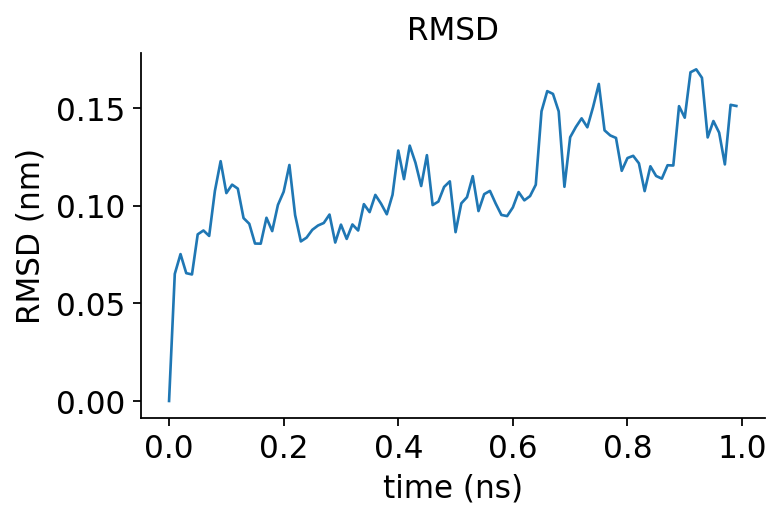

In [5]:
ax = ov.mol.plot_rmsd(traj)
plt.show()

In [6]:
r = ov.mol.rmsd(traj)
print(f'CA-RMSD  mean {r.mean():.3f} nm | final {r[-1]:.3f} | max {r.max():.3f}')

CA-RMSD  mean 0.111 nm | final 0.151 | max 0.170


## 4. Where is it flexible?

RMSF is the per-residue flexibility profile — the physics-based answer to
"which parts of my model are floppy?", complementary to pLDDT (which is only
the predictor's own confidence).

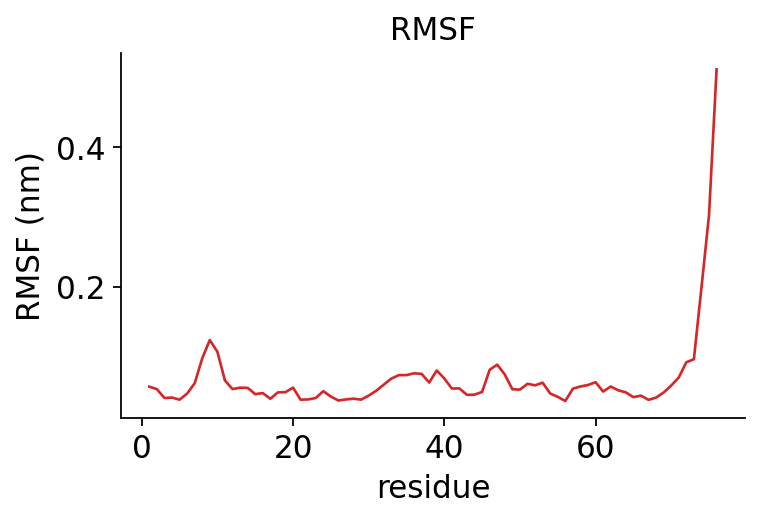

In [7]:
ax = ov.mol.plot_rmsf(traj)
plt.show()

In [8]:
import numpy as np
f = ov.mol.rmsf(traj)
print('most flexible residues:', (np.argsort(f)[-5:] + 1).tolist())
print(f'core RMSF {np.median(f):.3f} nm vs peak {f.max():.3f} nm')

most flexible residues: [10, 9, 74, 75, 76]
core RMSF 0.053 nm vs peak 0.512 nm


The peak should land on the **C-terminal Leu73-Arg74-Gly75-Gly76
tail** — the segment ubiquitin uses to conjugate onto substrates, and which is
genuinely disordered in solution. That the simulation finds it without being
told is a good sign the setup is sound.

## 5. Compactness and secondary structure

Radius of gyration tracks global size; DSSP tracks whether the helices and
sheets survive.

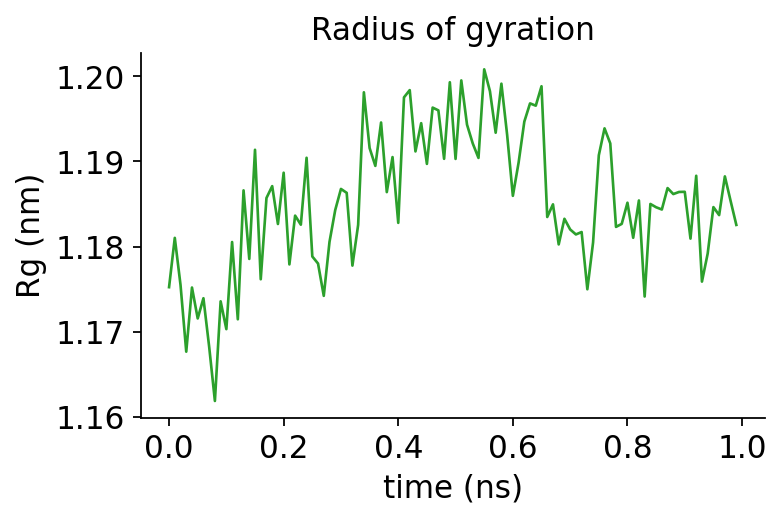

In [9]:
ax = ov.mol.plot_rg(traj)
plt.show()

In [10]:
rg = ov.mol.radius_of_gyration(traj)
ss = ov.mol.secondary_structure(traj)
print(f'Rg {rg.mean():.3f} +/- {rg.std():.3f} nm   (ubiquitin, literature ~1.17)')
print(f'helix {(ss == "H").mean():.2f} | sheet {(ss == "E").mean():.2f} | coil {(ss == "C").mean():.2f}')

Rg 1.185 +/- 0.008 nm   (ubiquitin, literature ~1.17)
helix 0.19 | sheet 0.34 | coil 0.47


## 6. Which contacts actually persist?

Hydrogen bonds present in most frames — the interactions holding the fold
together (or, for a complex, holding the ligand in place).

In [11]:
hb = ov.mol.hbonds(traj, freq=0.6)
print(f'{len(hb)} hydrogen bonds present in >60% of frames')
hb.head()

50 hydrogen bonds present in >60% of frames


,donor_residue,donor_atom,hydrogen,acceptor_residue,acceptor_atom,occupancy
0,PHE4,N,H,SER65,O,1.0
1,VAL5,N,H,ILE13,O,1.0
2,ILE23,N,H,ARG54,O,1.0
3,VAL17,N,H,MET1,O,1.0
4,ASP21,N,H,GLU18,O,1.0


## 7. Conformational states

Clustering the frames by pairwise RMSD finds the distinct states visited. The
medoid frames are representative structures you can send back to
`ov.mol.view`.

In [12]:
labels, medoids = ov.mol.cluster(traj, n_clusters=3)
print('cluster sizes:', [int((labels == c).sum()) for c in sorted(set(labels))])
print('representative frames:', medoids.tolist())

cluster sizes: [26, 36, 38]
representative frames: [51, 88, 15]


## 8. Stage-by-stage control — *when the defaults are not what you want*

`simulate` is an orchestration of four functions. Call them yourself for a
different restraint scheme, a longer equilibration, implicit solvent, or a
4 fs timestep with hydrogen-mass repartitioning.

**Implicit solvent** (GBn2) drops the water box entirely — far faster, and a
good choice for long sampling when explicit solvation structure does not
matter.

In [13]:
sysobj = ov.mol.prepare_system(s, water='implicit', hmr=True, seed=0)
sysobj

MDSystem(1231 atoms, amber14-all/implicit)

Minimisation is not optional — it relieves the clashes left by
structure repair and solvation. Skipping it is the most common cause of a
`Particle coordinate is NaN` blow-up.

In [14]:
sysobj = ov.mol.minimize(sysobj)

   OpenMM platform: CUDA (precision=mixed)


   minimisation: -1865.4 -> -14500.6 kJ/mol


In [15]:
sysobj = ov.mol.equilibrate(sysobj, nvt_ps=100, npt_ps=0, seed=0)

   OpenMM platform: CUDA (precision=mixed)


   NVT 100 ps @ 300 K (restraint 'heavy', k=1000)


   equilibrated: potential energy -10773.0 kJ/mol


`hmr=True` allows a **4 fs** timestep instead of 2 fs, roughly
doubling throughput. The guard refuses 4 fs on a system built without HMR,
because it would be unstable.

In [16]:
traj2 = ov.mol.production(sysobj, ns=2.0, timestep_fs=4.0, ensemble='NVT',
                          report_ps=10.0, traj='md_implicit/prod.dcd', seed=0)
traj2

   OpenMM platform: CUDA (precision=mixed)
   production: 2 ns, 500000 steps @ 4 fs, NVT, frame every 10 ps -> md_implicit/prod.dcd


#"Step"	"Time (ps)"	"Potential Energy (kJ/mole)"	"Temperature (K)"	"Speed (ns/day)"	"Time Remaining"


50000	199.9999999998967	-10837.636051786785	302.32555650739266	0	--


100000	400.0000000004537	-10599.096309643399	292.64286698955556	88.5	26:02


150000	600.0000000014087	-10714.410527386057	308.2034512645991	83.2	24:13


...

400000	1599.9999999898125	-10865.177639652553	311.4517413583805	77.6	7:25


450000	1799.9999999850832	-10651.282804505581	304.115226527518	75.7	3:48


500000	1999.9999999803538	-10714.889314835986	305.3955572334219	74.5	0:00


   done: 200 frames on platform CUDA


MDTrajectory(200 frames, 2.000 ns @ 10 ps/frame, 'prod.dcd')

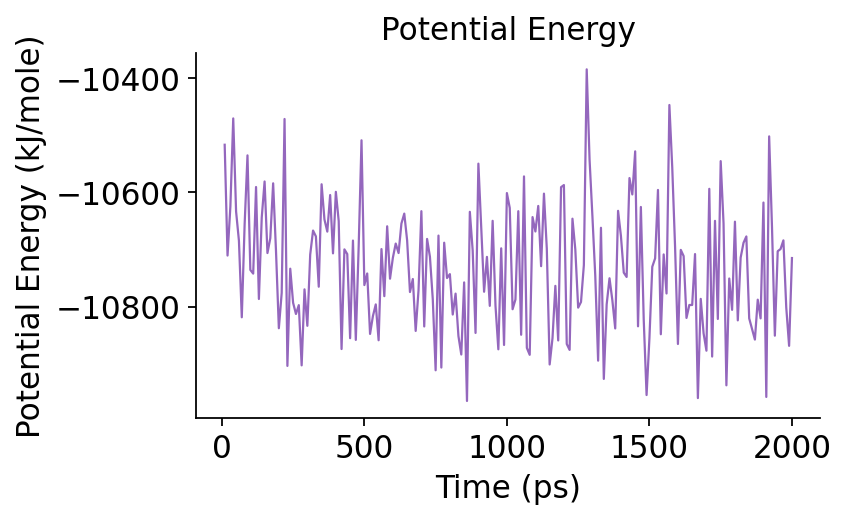

In [17]:
ax = ov.mol.plot_energy(traj2)
plt.show()

## 9. dock → MD → MM-GBSA — *rescoring a pose with dynamics*

This is the part docking alone cannot do.

`ov.mol.dock` returns a **static** pose with a Vina score: a single-point
estimate on a rigid receptor. What we want to know is whether the pose
*stays*, and what the binding energy looks like over a real ensemble.

Because the `DockingResult` carries its receptor, it can be handed straight to
`simulate`, and the resulting trajectory to `mmgbsa`.

> Simulating a protein–**ligand** complex needs small-molecule
> parameterisation, and AM1-BCC charges come from AmberTools:
> `conda install -c conda-forge openmmforcefields openff-toolkit ambertools`

In [18]:
egfr = ov.mol.fetch_structure('1M17', source='pdb')
ov.mol.pockets(egfr).head(3)

,pocket_id,rank,drug_score,volume,n_alpha_spheres,hydrophobicity_score,polarity_score,n_residues,residues
0,1,1,0.336140,486.480887,49,36.545455,5.0,11,"[(A, 702), (A, 721), (A, 719), (A, 766), (A, 6..."
1,11,2,0.116385,283.182123,27,43.375000,3.0,8,"[(A, 676), (A, 678), (A, 740), (A, 744), (A, 6..."
2,7,3,0.043613,224.191045,23,4.222222,7.0,9,"[(A, 855), (A, 889), (A, 856), (A, 779), (A, 7..."


In [19]:
erlotinib = 'CCOCCOc1cc2ncnc(Nc3cccc(C#C)c3)c2cc1OCCOC'
result = ov.mol.dock(egfr, erlotinib, pocket=1, seed=42)
result

DockingResult(8 poses, best -7.18 kcal/mol)

In [20]:
print(f'static Vina score: {result.affinities[0]:.2f} kcal/mol')

static Vina score: -7.18 kcal/mol


Now relax that pose with real dynamics. `simulate` rebuilds the
receptor plus the top pose as a single complex — the ligand is parameterised
with GAFF and named `LIG` in the topology.

In [21]:
cplx = ov.mol.simulate(result, ns=1.0, water='implicit',
                       outdir='md_egfr', seed=0)
cplx

🧬 ov.mol.simulate — 1 ns, output in md_egfr/
   fixing structure (receptor_input.pdb) at pH 7.0


   parameterising ligand with gaff-2.11


   AM1-BCC charges assigned (from a generated conformer)


   system ready: 5084 particles
   OpenMM platform: CUDA (precision=mixed)


   minimisation: 26118.2 -> -48574.8 kJ/mol
   implicit solvent: skipping the NPT stage (no box)
   OpenMM platform: CUDA (precision=mixed)


...

400000	799.9999999949063	-34056.8630638937	303.8507933418971	50.8	5:39


450000	899.9999999925416	-34031.09280948312	296.1337207634839	52.3	2:45


500000	999.9999999901769	-33796.755781608575	299.48316682075705	53.6	0:00


   done: 100 frames on platform CUDA


MDTrajectory(100 frames, 1.000 ns @ 10 ps/frame, 'prod.dcd')

Did the ligand stay in the pocket? Count protein–ligand contacts
per frame; a pose that drifts out shows the count collapsing towards zero.

/scratch/users/steorra/env/ovmd/lib/python3.10/site-packages/mdtraj/core/selection.py:397: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse_result = self.expression.parseString(selection, parseAll=True)
/scratch/users/steorra/env/ovmd/lib/python3.10/site-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)


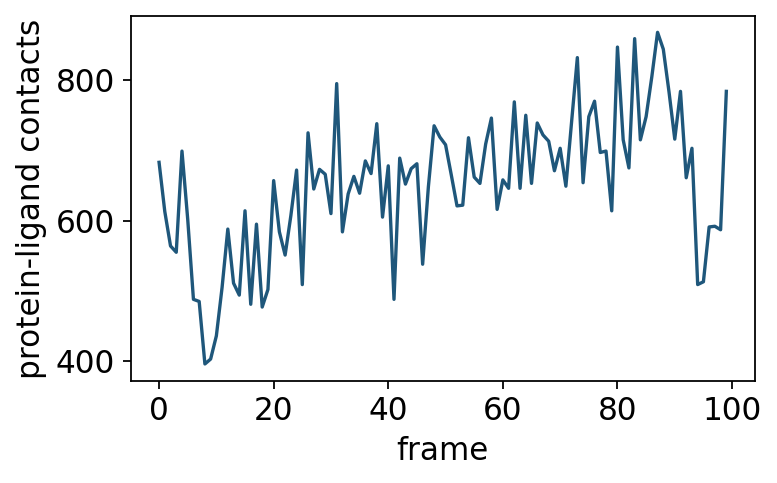

In [22]:
n_contacts = ov.mol.contacts(cplx, 'protein', 'resname LIG')
plt.figure(figsize=(5, 3))
plt.plot(n_contacts)
plt.xlabel('frame'); plt.ylabel('protein-ligand contacts'); plt.show()

In [23]:
print(f'contacts: first {n_contacts[0]}, mean {n_contacts.mean():.0f}, last {n_contacts[-1]}')

contacts: first 683, mean 652, last 784


Finally, rescore over the ensemble with **MM-GBSA**:

$$\Delta G_{bind} = \langle G_{complex}\rangle - \langle G_{receptor}\rangle - \langle G_{ligand}\rangle$$

decomposed into van der Waals, electrostatic, polar solvation (GBn2) and
non-polar (surface-area) terms.

In [24]:
res = ov.mol.mmgbsa(cplx, frames=20)
res

   OpenMM platform: CUDA (precision=mixed)


/scratch/users/steorra/env/ovmd/lib/python3.10/site-packages/mdtraj/core/selection.py:397: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse_result = self.expression.parseString(selection, parseAll=True)
/scratch/users/steorra/env/ovmd/lib/python3.10/site-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)


   scoring 20 of 100 frames (GBn2 implicit solvent)


   dG = -39.50 +/- 1.11 kcal/mol (vdW -45.5, elec -10.9, polar 24.1, nonpolar -7.2)


MMGBSAResult(dG = -39.50 +/- 1.11 kcal/mol, 20 frames)

In [25]:
res.to_frame().round(2)

,dG_kcal_mol,std,sem,n_frames,vdw_kcal_mol,electrostatic_kcal_mol,polar_solvation_kcal_mol,nonpolar_solvation_kcal_mol
0,-39.5,4.97,1.11,20,-45.48,-10.91,24.06,-7.18


## Interpretation

**The fold is stable.** RMSD plateaus around 0.15 nm, Rg holds at the
literature value (~1.17 nm), and the secondary structure survives — this
model can carry downstream work.

**Flexibility is where biology says it should be.** The RMSF peak is the
C-terminal Gly-Gly tail that ubiquitin uses for conjugation. A prediction
confidence score cannot tell you that; dynamics can.

**Reading the MM-GBSA number honestly.** End-point MM-GBSA is a **relative
ranking** tool, not an experimental binding free energy:

- it systematically **overestimates** affinity, often by 5–20 kcal/mol;
- it includes **no entropy** term;
- it uses implicit solvent, so bridging waters are invisible.

Use it to rank a congeneric series against itself, and always quote the spread
(`res.sem`) with the mean. For rigorous absolute free energies you need
alchemical FEP/TI — `ov.mol.alchemical_free_energy` documents why that is a
much more expensive undertaking and is deliberately not implemented here.

What you *have* gained over plain docking is real: the pose was relaxed in a
force field with a thermostat, you can see whether it stayed bound, and the
score is an ensemble average rather than one rigid snapshot.

**Reproducibility.** `seed` controls every stochastic step — hydrogen
placement, water and ion positions, initial velocities, thermostat and
barostat. Given the same `MDSystem`, `seed`, `platform` and `precision`, a run
repeats bit-for-bit. Across *different* platforms or precisions trajectories
diverge, because MD is chaotic; compare ensemble properties, not individual
frames. Every result object carries a `provenance` dict (engine versions,
forcefield, integrator, seed, platform, file hashes).

**Next steps.** `ov.mol.production` writes checkpoints — continue a run with
`resume=traj.checkpoint`. For a different target, everything here works
unchanged on an AlphaFold model from `ov.mol.predict_structure`.